<a href="https://colab.research.google.com/github/saizaw14/Ecoloop/blob/main/EcoLoop_Waste_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import shutil

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
dataset_dir = "/content/dataset/dataset-resized"

class_names = sorted([
    folder for folder in os.listdir(dataset_dir)
    if os.path.isdir(os.path.join(dataset_dir, folder))
])

print("Classes:", class_names)

for class_name in class_names:
    class_path = os.path.join(dataset_dir, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    name="mobilenetv2_base"
)

base_model.trainable = False

global_average_layer = layers.GlobalAveragePooling2D(name="global_average_pooling")
dropout_layer = layers.Dropout(0.3, name="dropout")
prediction_layer = layers.Dense(len(class_names), activation="softmax", name="prediction")

inputs = layers.Input(shape=(224, 224, 3), name="image")
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = dropout_layer(x)
outputs = prediction_layer(x)

model = models.Model(inputs, outputs, name="ecoloop_training_model")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ecoloop_training_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_base (Functional)   │ (None, 7, 7, 1280)     │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.2493 - loss: 1.9337 - val_accuracy: 0.3188 - val_loss: 1.6149
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.3724 - loss: 1.5700 - val_accuracy: 0.4851 - val_loss: 1.3627
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.4530 - loss: 1.3822 - val_accuracy: 0.5762 - val_loss: 1.1964
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.5321 - loss: 1.2315 - val_accuracy: 0.6277 - val_loss: 1.0796
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.5969 - loss: 1.1052 - val_accuracy: 0.6733 - val_loss: 0.9916
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.6034 - loss: 1.0500 - val_accuracy: 0.6911 - val_loss: 0.9269
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.6395 - loss: 0.9737 - val_accuracy: 0.7109 - val_loss: 0.8753
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.6563 - loss: 0.9298 - val_accuracy: 0.

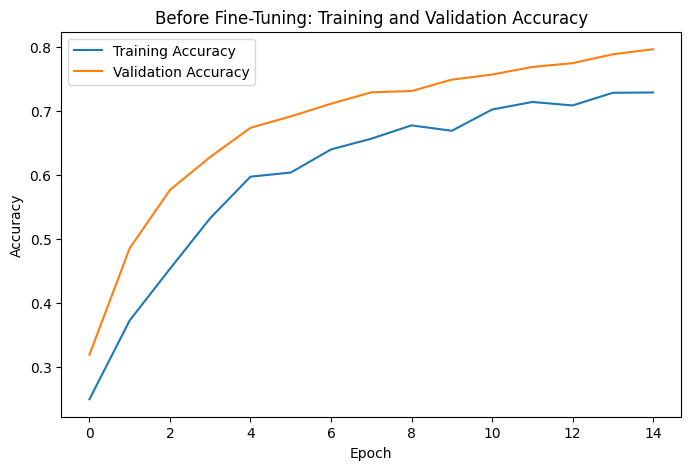

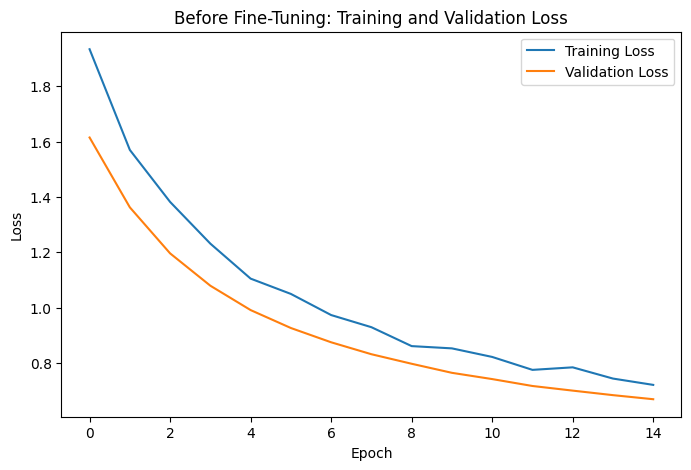

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Before Fine-Tuning: Training and Validation Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Before Fine-Tuning: Training and Validation Loss")
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.7960 - loss: 0.6697
Before Fine-Tuning Validation Loss: 0.6697379350662231
Before Fine-Tuning Validation Accuracy: 0.7960395812988281
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Before Fine-Tuning Classification Report
              precision    recall  f1-score   support

   cardboard       0.82      0.90      0.86        69
       glass       0.77      0.87      0.82

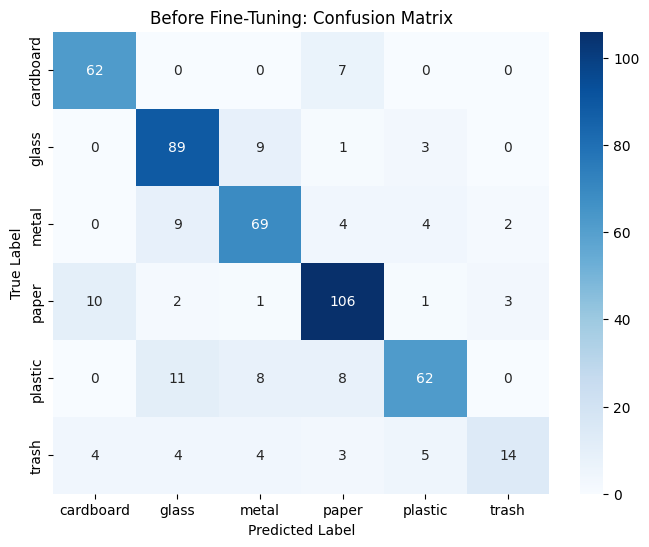

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

initial_val_loss, initial_val_accuracy = model.evaluate(val_ds)

print("Before Fine-Tuning Validation Loss:", initial_val_loss)
print("Before Fine-Tuning Validation Accuracy:", initial_val_accuracy)

y_true_initial = []
y_pred_initial = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_initial.extend(labels.numpy())
    y_pred_initial.extend(predicted_labels)

print("Before Fine-Tuning Classification Report")
print(classification_report(y_true_initial, y_pred_initial, target_names=class_names))

cm_initial = confusion_matrix(y_true_initial, y_pred_initial)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_initial,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Before Fine-Tuning: Confusion Matrix")
plt.show()

In [ ]:
model.save("/content/ecoloop_initial_model.keras")
print("Initial model saved successfully!")

Initial model saved successfully!


In [ ]:
base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

FINE_TUNE_EPOCHS = 10

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 180ms/step - accuracy: 0.6330 - loss: 1.0109 - val_accuracy: 0.7921 - val_loss: 0.6448
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.6978 - loss: 0.8244 - val_accuracy: 0.7960 - val_loss: 0.6292
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.7404 - loss: 0.7435 - val_accuracy: 0.8040 - val_loss: 0.6079
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.7552 - loss: 0.6719 - val_accuracy: 0.8099 - val_loss: 0.5869
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.7844 - loss: 0.6166 - val_accuracy: 0.8139 - val_loss: 0.5666
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.8017 - loss: 0.5702 - val_accuracy: 0.8218 - val_loss: 0.5509
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.8145 - loss: 0.5317 - val_accuracy: 0.8297 - val_loss: 0.5355
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8234 - loss: 0.5038 - val_accurac

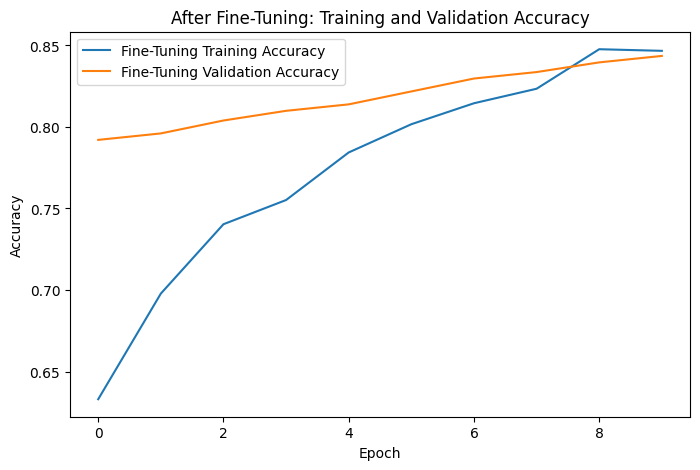

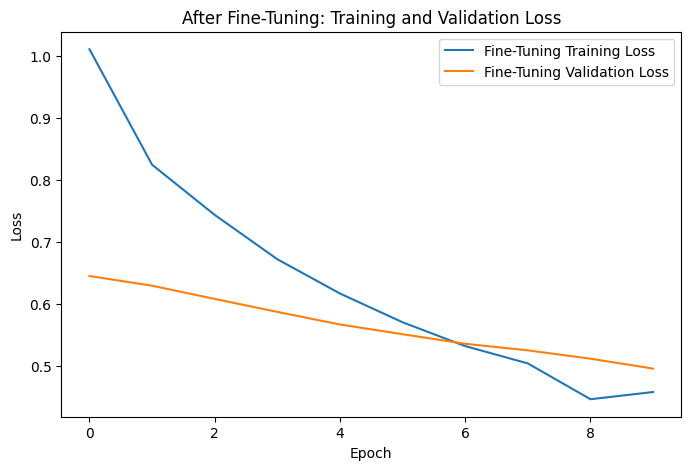

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["accuracy"], label="Fine-Tuning Training Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Fine-Tuning Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("After Fine-Tuning: Training and Validation Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["loss"], label="Fine-Tuning Training Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Fine-Tuning Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("After Fine-Tuning: Training and Validation Loss")
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8436 - loss: 0.4954
After Fine-Tuning Validation Loss: 0.49542009830474854
After Fine-Tuning Validation Accuracy: 0.8435643315315247
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
After Fine-Tuning Classification Report
              precision    recall  f1-score   support

   cardboard       0.85      0.90      0.87        69
       glass       0.85      0.88      0.87  

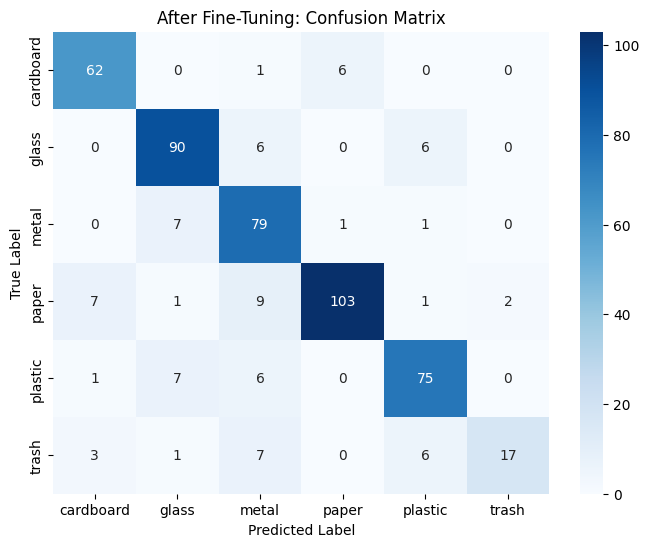

In [ ]:
final_val_loss, final_val_accuracy = model.evaluate(val_ds)

print("After Fine-Tuning Validation Loss:", final_val_loss)
print("After Fine-Tuning Validation Accuracy:", final_val_accuracy)

y_true_final = []
y_pred_final = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_final.extend(labels.numpy())
    y_pred_final.extend(predicted_labels)

print("After Fine-Tuning Classification Report")
print(classification_report(y_true_final, y_pred_final, target_names=class_names))

cm_final = confusion_matrix(y_true_final, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("After Fine-Tuning: Confusion Matrix")
plt.show()

In [ ]:
model.save("/content/ecoloop_waste_model.keras")
print("Final fine-tuned model saved successfully!")

Final fine-tuned model saved successfully!


In [ ]:
inference_input = tf.keras.Input(shape=(224, 224, 3), name="image")

# App will do preprocessing:
# pixel / 127.5 - 1.0
x = base_model(inference_input, training=False)
x = global_average_layer(x)
x = dropout_layer(x, training=False)
inference_output = prediction_layer(x)

inference_model = tf.keras.Model(
    inference_input,
    inference_output,
    name="ecoloop_inference"
)

inference_model.summary()

Model: "ecoloop_inference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_base (Functional)   │ (None, 7, 7, 1280)     │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 1,869,126 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
for images, labels in val_ds.take(1):
    preprocessed_images = tf.keras.applications.mobilenet_v2.preprocess_input(images)
    predictions = inference_model.predict(preprocessed_images)

    print("Prediction shape:", predictions.shape)
    print("Sample prediction:", predictions[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
Prediction shape: (32, 6)
Sample prediction: [8.5474527e-04 2.1817416e-02 5.2668420e-05 1.1546256e-03 9.7186768e-01
 4.2528813e-03]


In [ ]:
inference_model.save("/content/ecoloop_inference.h5", include_optimizer=False)
print("Saved clean inference H5 model.")

Saved clean inference H5 model.


In [ ]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting un

In [ ]:
!tensorflowjs_converter \
  --input_format=keras \
  --output_format=tfjs_layers_model \
  /content/ecoloop_inference.h5 \
  /content/ecoloop_tfjs_legacy

2026-05-30 08:29:54.174098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780129794.243385   12916 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780129794.254539   12916 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780129794.282852   12916 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780129794.282892   12916 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780129794.282900   12916 computation_placer.cc:177] computation placer alr

In [ ]:
# Build clean inference-only model again
inference_input = tf.keras.Input(shape=(224, 224, 3), name="image")

# App will do preprocessing:
# pixel / 127.5 - 1.0
x = base_model(inference_input, training=False)
x = global_average_layer(x)
x = dropout_layer(x, training=False)
inference_output = prediction_layer(x)

inference_model = tf.keras.Model(
    inference_input,
    inference_output,
    name="ecoloop_inference"
)

inference_model.summary()

NameError: name 'tf' is not defined

In [ ]:
import tensorflow as tf
import os
import shutil

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
model = tf.keras.models.load_model("/content/ecoloop_waste_model.keras")
model.summary()

Model: "ecoloop_training_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_base (Functional)   │ (None, 7, 7, 1280)     │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,003,924 (22.90 MB)

 Trainable params: 1,869,126 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 3,738,254 (14.26 MB)

In [ ]:
base_model = model.get_layer("mobilenetv2_base")
global_average_layer = model.get_layer("global_average_pooling")
dropout_layer = model.get_layer("dropout")
prediction_layer = model.get_layer("prediction")

print("Layers loaded successfully.")

Layers loaded successfully.


In [ ]:
inference_input = tf.keras.Input(shape=(224, 224, 3), name="image")

# App will do preprocessing before prediction:
# pixel / 127.5 - 1.0
x = base_model(inference_input, training=False)
x = global_average_layer(x)
x = dropout_layer(x, training=False)
inference_output = prediction_layer(x)

inference_model = tf.keras.Model(
    inference_input,
    inference_output,
    name="ecoloop_inference"
)

inference_model.summary()

Model: "ecoloop_inference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_base (Functional)   │ (None, 7, 7, 1280)     │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 1,869,126 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
tf.saved_model.save(inference_model, "/content/ecoloop_saved_model")

print("SavedModel exported successfully!")

SavedModel exported successfully!


In [ ]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  --signature_name=serving_default \
  --saved_model_tags=serve \
  /content/ecoloop_saved_model \
  /content/ecoloop_tfjs_graph_model

2026-05-30 08:34:57.695291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780130097.728560   14225 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780130097.740068   14225 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780130097.765119   14225 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780130097.765156   14225 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780130097.765165   14225 computation_placer.cc:177] computation placer alr

In [ ]:
import os

print(os.listdir("/content/ecoloop_tfjs_graph_model"))

['group1-shard3of3.bin', 'group1-shard1of3.bin', 'group1-shard2of3.bin', 'model.json']


In [ ]:
import shutil

shutil.make_archive(
    "/content/ecoloop_tfjs_graph_model",
    "zip",
    "/content/ecoloop_tfjs_graph_model"
)

print("TFJS GraphModel zipped successfully!")

TFJS GraphModel zipped successfully!


In [ ]:
class_names = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

with open("/content/labels.txt", "w") as f:
    for class_name in class_names:
        f.write(class_name + "\n")

print("labels.txt created successfully!")
print(class_names)

labels.txt created successfully!
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
